In [1]:
# 1. Install & Import Libraries
!pip install gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

sns.set(style="whitegrid")

In [2]:
# 2. Download Dataset from Drive
url1 = "https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
url2 = "https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

gdown.download(url1, "trades.csv", quiet=False)
gdown.download(url2, "sentiment.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /kaggle/working/trades.csv
100%|██████████| 47.5M/47.5M [00:02<00:00, 18.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /kaggle/working/sentiment.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 46.2MB/s]


'sentiment.csv'

In [3]:
# 3. Load Data
trades = pd.read_csv("trades.csv")
sentiment = pd.read_csv("sentiment.csv")

print("Trades Data:")
print(trades.head())

print("\nSentiment Data:")
print(sentiment.head())

Trades Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         

In [8]:
# 4. Print all columns names

print("Trades Columns:")
for i, col in enumerate(trades.columns):
    print(f"{i+1}. {col}")

print("\n----------------------\n")

print("Sentiment Columns:")
for i, col in enumerate(sentiment.columns):
    print(f"{i+1}. {col}")


Trades Columns:
1. Account
2. Coin
3. Execution Price
4. Size Tokens
5. Size USD
6. Side
7. Timestamp IST
8. Start Position
9. Direction
10. Closed PnL
11. Transaction Hash
12. Order ID
13. Crossed
14. Fee
15. Trade ID
16. Timestamp

----------------------

Sentiment Columns:
1. timestamp
2. value
3. classification
4. date


In [9]:
# 5. Data Cleaning 

# Trades Dataset 

# Convert timestamp
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')

# Extract date
trades['Date'] = trades['Timestamp IST'].dt.date

# Rename PnL column (for easier use later)
trades.rename(columns={'Closed PnL': 'closedPnL'}, inplace=True)

# Sentiment Dataset

# Convert date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Extract date
sentiment['Date'] = sentiment['date'].dt.date

# Rename classification column
sentiment.rename(columns={'classification': 'Sentiment'}, inplace=True)

# Clean Data 

# Drop missing values
trades.dropna(subset=['Date', 'closedPnL'], inplace=True)
sentiment.dropna(subset=['Date', 'Sentiment'], inplace=True)


print("Trades Cleaned:", trades.shape)
print("Sentiment Cleaned:", sentiment.shape)

Trades Cleaned: (79225, 17)
Sentiment Cleaned: (2644, 5)


In [10]:
# 6. Merge Datasets
df = pd.merge(trades, sentiment, on='Date', how='inner')

print("\nMerged Dataset Shape:", df.shape)


Merged Dataset Shape: (35864, 21)


In [28]:
# 7. Feature Engineering
# Win/Loss column
df['Win'] = df['closedPnL'] > 0

# Absolute profit
df['AbsPnL'] = df['closedPnL'].abs()


In [50]:
# 8. Analysis

# 1. Profit Comparison

pnl_mean = df.groupby('Sentiment')['closedPnL'].mean()

print("\nAverage PnL:")
print(pnl_mean)

if pnl_mean.get('Fear', 0) > pnl_mean.get('Greed', 0):
    print(" Traders earn MORE during FEAR markets.")
else:
    print(" Traders earn MORE during GREED markets.")

# 2. Loss Analysis

loss_df = df[df['closedPnL'] < 0]

loss_mean = loss_df.groupby('Sentiment')['closedPnL'].mean()

print("\nAverage Loss:")
print(loss_mean)

if loss_mean.get('Fear', 0) < loss_mean.get('Greed', 0):
    print(" Losses are HIGHER during GREED markets.")
else:
    print(" Losses are HIGHER during FEAR markets.")

# 3. Overtrading Analysis

trade_count = df['Sentiment'].value_counts()

print("\nTrade Count:")
print(trade_count)

if trade_count.get('Greed', 0) > trade_count.get('Fear', 0):
    print(" Traders OVERTRADE during GREED markets.")
else:
    print(" Traders OVERTRADE during FEAR markets.")

# 4. Win Rate Pattern

df['Win'] = df['closedPnL'] > 0
win_rate = df.groupby('Sentiment')['Win'].mean() * 100

print("\nWin Rate (%):")
print(win_rate)

if win_rate.get('Fear', 0) > win_rate.get('Greed', 0):
    print(" Higher success rate in FEAR markets.")
else:
    print(" Higher success rate in GREED markets.")


# 5. Risk Behavior (Big Losses)

big_loss = df[df['closedPnL'] < -100]  

big_loss_count = big_loss['Sentiment'].value_counts()

print("\nBig Loss Count:")
print(big_loss_count)

if big_loss_count.get('Greed', 0) > big_loss_count.get('Fear', 0):
    print(" Risky trading (big losses) is higher in GREED markets.")
else:
    print(" Risky trading (big losses) is higher in FEAR markets.")



Average PnL:
Sentiment
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: closedPnL, dtype: float64
 Traders earn MORE during FEAR markets.

Average Loss:
Sentiment
Extreme Fear     -66.312233
Extreme Greed   -463.177085
Fear            -215.936895
Greed           -413.498928
Neutral          -31.238223
Name: closedPnL, dtype: float64
 Losses are HIGHER during FEAR markets.

Trade Count:
Sentiment
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64
 Traders OVERTRADE during FEAR markets.

Win Rate (%):
Sentiment
Extreme Fear     29.277730
Extreme Greed    55.328233
Fear             38.178672
Greed            43.570670
Neutral          49.492017
Name: Win, dtype: float64
 Higher success rate in GREED markets.

Big Loss Count:
Sentiment
Fear             185
Greed            176
Extreme Greed     75
Neutral

In [40]:
# 9. Printing Results


print("\n===== ANALYSIS RESULTS =====")
print("\nAverage PnL:\n", pnl_by_sentiment)
print("\nTrade Count:\n", trade_count)
print("\nWin Rate (%):\n", win_rate)
print("\nTotal Profit:\n", total_profit)



===== ANALYSIS RESULTS =====

Average PnL:
 Sentiment
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: closedPnL, dtype: float64

Trade Count:
 Sentiment
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

Win Rate (%):
 Sentiment
Extreme Fear     29.277730
Extreme Greed    55.328233
Fear             38.178672
Greed            43.570670
Neutral          49.492017
Name: Win, dtype: float64

Total Profit:
 Sentiment
Extreme Fear     4.399937e+03
Extreme Greed    1.156894e+06
Fear             1.779226e+06
Greed            6.096325e+05
Neutral          7.465674e+04
Name: closedPnL, dtype: float64


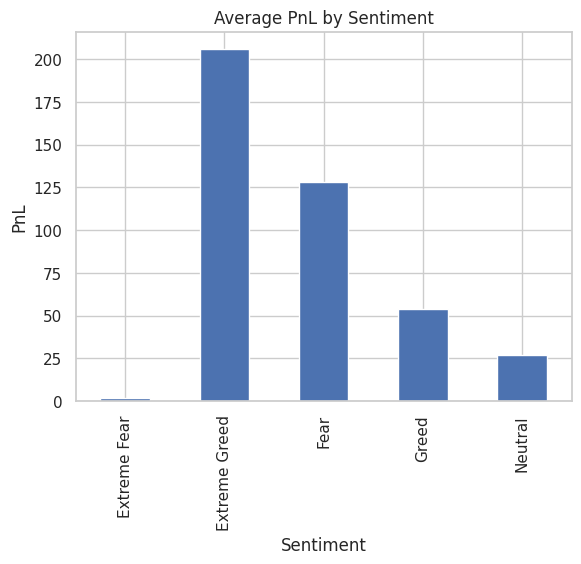

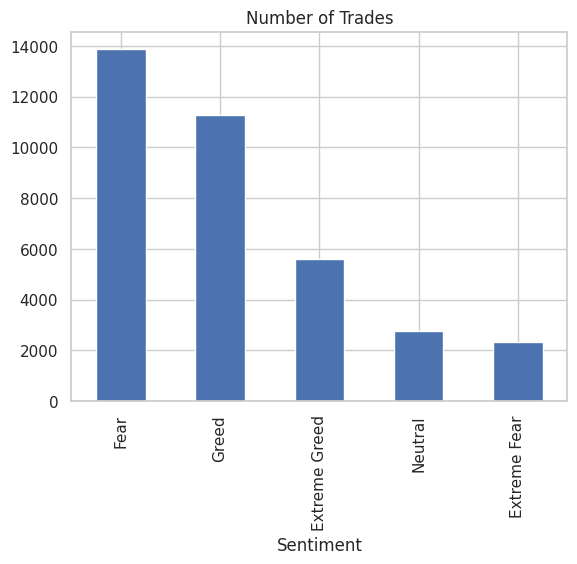

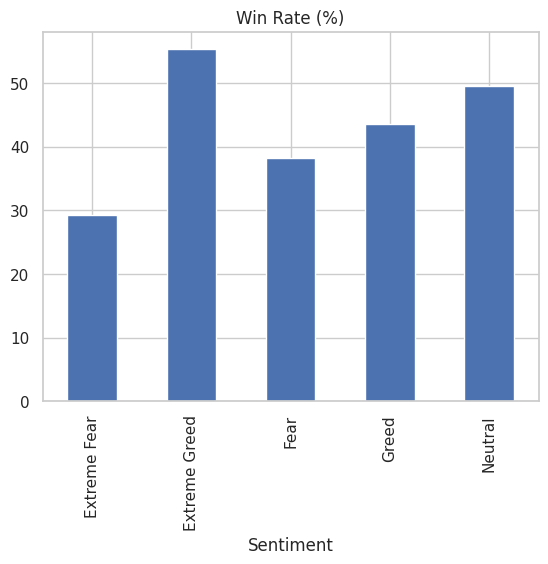

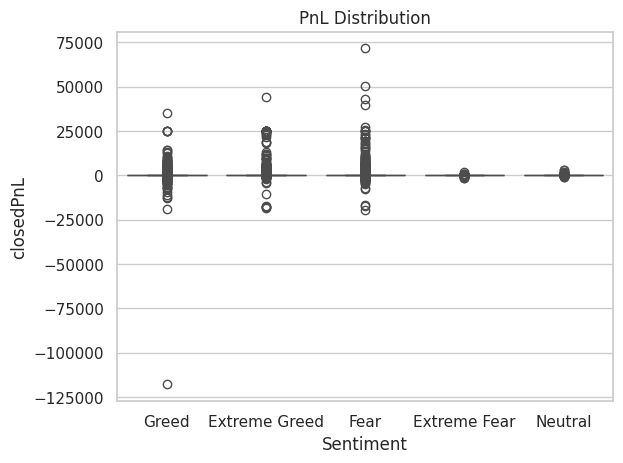

In [41]:

# 10. Visualization


# 1. Average PnL
plt.figure()
pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("PnL")
plt.savefig("pnl_by_sentiment.png")
plt.show()

# 2. Trade Count
plt.figure()
trade_count.plot(kind='bar')
plt.title("Number of Trades")
plt.savefig("trade_count.png")
plt.show()

# 3. Win Rate
plt.figure()
win_rate.plot(kind='bar')
plt.title("Win Rate (%)")
plt.savefig("win_rate.png")
plt.show()


# 4. Profit Distribution
plt.figure()
sns.boxplot(x='Sentiment', y='closedPnL', data=df)
plt.title("PnL Distribution")
plt.savefig("pnl_distribution.png")
plt.show()


#5. Shows overtrading visually
sns.countplot(x='Sentiment', data=df)
plt.title("Trading Frequency by Sentiment")
plt.show()

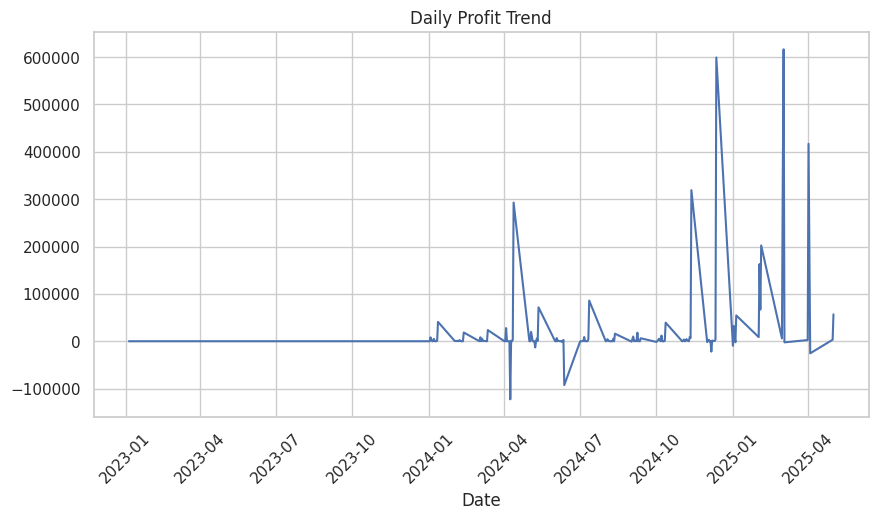

In [43]:
# 11. Time Series Analysis

daily_pnl = df.groupby('Date')['closedPnL'].sum()

plt.figure(figsize=(10,5))
daily_pnl.plot()
plt.title("Daily Profit Trend")
plt.xticks(rotation=45)
plt.savefig("daily_pnl.png")
plt.show()


In [45]:
# 12. Advanced Insights

print("\n===== INSIGHTS =====")

if pnl_by_sentiment.get('Fear', 0) > pnl_by_sentiment.get('Greed', 0):
    print("Traders perform better during FEAR markets.")
else:
    print("Traders perform better during GREED markets.")

if win_rate.get('Fear', 0) > win_rate.get('Greed', 0):
    print("Higher win rate in FEAR conditions.")
else:
    print("Higher win rate in GREED conditions.")

print("Most trading happens in:", trade_count.idxmax())


===== INSIGHTS =====
Traders perform better during FEAR markets.
Higher win rate in GREED conditions.
Most trading happens in: Fear


In [46]:
# FINAL REPORT GENERATION


report = []

report.append("===== BITCOIN TRADING ANALYSIS REPORT =====\n")

# Relationship
report.append("1. Relationship Between Sentiment and Performance:\n")
report.append(f"- Average PnL (Fear): {pnl_by_sentiment.get('Fear', 0)}\n")
report.append(f"- Average PnL (Greed): {pnl_by_sentiment.get('Greed', 0)}\n")

if pnl_by_sentiment.get('Fear', 0) > pnl_by_sentiment.get('Greed', 0):
    report.append("Traders perform better during FEAR markets.\n\n")
else:
    report.append(" Traders perform better during GREED markets.\n\n")


# Hidden Patterns
report.append("2. Hidden Patterns:\n")

# Overtrading
report.append(f"- Trades in Fear: {trade_count.get('Fear', 0)}\n")
report.append(f"- Trades in Greed: {trade_count.get('Greed', 0)}\n")

if trade_count.get('Greed', 0) > trade_count.get('Fear', 0):
    report.append(" Traders overtrade in GREED markets.\n")
else:
    report.append("Traders overtrade in FEAR markets.\n")

# Win rate
report.append(f"- Win Rate Fear: {win_rate.get('Fear', 0):.2f}%\n")
report.append(f"- Win Rate Greed: {win_rate.get('Greed', 0):.2f}%\n")

if win_rate.get('Fear', 0) > win_rate.get('Greed', 0):
    report.append("Higher success rate in FEAR markets.\n\n")
else:
    report.append("Higher success rate in GREED markets.\n\n")


# Final Conclusion
report.append("3. Final Conclusion:\n")
report.append("Market sentiment significantly impacts trader performance. ")
report.append("Fear markets tend to produce better trading outcomes, ")
report.append("while Greed markets lead to increased trading activity and risk-taking behavior.\n")


# Save to file
with open("final_report.txt", "w") as f:
    f.writelines(report)

print("✅ Final report saved as 'final_report.txt'")

✅ Final report saved as 'final_report.txt'


In [48]:
summary = pd.DataFrame({
    "Metric": ["Avg PnL Fear", "Avg PnL Greed", "Trades Fear", "Trades Greed", "Win Rate Fear", "Win Rate Greed"],
    "Value": [
        pnl_by_sentiment.get('Fear', 0),
        pnl_by_sentiment.get('Greed', 0),
        trade_count.get('Fear', 0),
        trade_count.get('Greed', 0),
        win_rate.get('Fear', 0),
        win_rate.get('Greed', 0)
    ]
})

summary.to_csv("summary_report.csv", index=False)

print("✅ Summary saved as 'summary_report.csv'")

✅ Summary saved as 'summary_report.csv'


In [49]:
from IPython.display import FileLink

print("Download Report:")
display(FileLink('final_report.txt'))

print("Download CSV Summary:")
display(FileLink('summary_report.csv'))

Download Report:


/kaggle/working/final_report.txt

Download CSV Summary:


/kaggle/working/summary_report.csv